In [1]:
import torch
from test_dataset import RDataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np 
from model import TeacherModel, StudentModel1, StudentModel2
import pickle
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
with open('reacher_episodes_full.pkl', 'rb') as f:
    frames = pickle.load(f)


In [4]:
observT, actionsT, targetsT= [], [], []
observS, actionsS, targetsS= [], [], []
count = 0
for i in frames:
    if count < 100:
        observT.append(i['observations'])
        actionsT.append(i['actions'])
        targetsT.append(i['targets'])

        observS.append(i['observations'])
        actionsS.append(i['actions'])
        targetsS.append(i['targets'])
    elif count < 600:
        observT.append(i['observations'])
        actionsT.append(i['actions'])
        targetsT.append(i['targets'])

    count += 1
print("Shape observ: ", observT[0].shape)
print("Shape actions: ", actionsT[0].shape)
print("Shape targets: ", targetsT[0].shape)

print("Shape observ: ", observS[0].shape)
print("Shape actions: ", actionsS[0].shape)
print("Shape targets: ", targetsS[0].shape)

Shape observ:  (66, 84, 84, 3)
Shape actions:  (66, 2)
Shape targets:  (66, 2)
Shape observ:  (66, 84, 84, 3)
Shape actions:  (66, 2)
Shape targets:  (66, 2)


In [5]:
observT = np.concatenate(observT, axis=0)
actionsT = np.concatenate(actionsT, axis=0)
targetsT = np.concatenate(targetsT, axis=0)

observS = np.concatenate(observS, axis=0)
actionsS = np.concatenate(actionsS, axis=0)
targetsS = np.concatenate(targetsS, axis=0)

print("Shape observ: ", observT[0].shape)
print("Shape actions: ", actionsT[0].shape)
print("Shape targets: ", targetsT[0].shape)

print("Shape observ: ", observS[0].shape)
print("Shape actions: ", actionsS[0].shape)
print("Shape targets: ", targetsS[0].shape)

Shape observ:  (84, 84, 3)
Shape actions:  (2,)
Shape targets:  (2,)
Shape observ:  (84, 84, 3)
Shape actions:  (2,)
Shape targets:  (2,)


In [ ]:
def dataset_loader(observ, actions, targets):
    transform = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

    # train/val split (80/20)
    N = len(observ)
    indices = np.random.permutation(N)
    split = int(0.8 * N)
    train_idx, val_idx = indices[:split], indices[split:]

    train_dataset = RDataset(
        observ[train_idx], actions[train_idx], targets[train_idx], transform
    )
    val_dataset = RDataset(
        observ[val_idx], actions[val_idx], targets[val_idx], transform
    )

    batch_size = 32
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )

    return train_loader, val_loader, train_dataset, val_dataset

In [7]:
def train_model(model, observ, actions, targets, model_name, modality=True,
                num_epochs=10, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    actions_mean = actions.mean(axis=0).astype(np.float32)
    actions_std  = actions.std(axis=0).astype(np.float32) + 1e-8
    actions_norm = ((actions - actions_mean) / actions_std).astype(np.float32)

    targets_mean = targets.mean(axis=0).astype(np.float32)
    targets_std  = targets.std(axis=0).astype(np.float32) + 1e-8
    targets_norm = ((targets - targets_mean) / targets_std).astype(np.float32)

    train_loader, val_loader, train_dataset, val_dataset = dataset_loader(
        observ, actions_norm, targets_norm
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_score, val_score = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for imgs, acts, target in train_loader:
            imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
            optimizer.zero_grad()
            outputs = model(imgs, target) if modality else model(imgs)
            loss = criterion(outputs, acts)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_dataset)
        train_score.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, acts, target in val_loader:
                imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
                outputs = model(imgs, target) if modality else model(imgs)
                loss = criterion(outputs, acts)
                val_loss += loss.item() * imgs.size(0)
        val_loss /= len(val_dataset)
        val_score.append(val_loss)

        scheduler.step()
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    torch.save({
        'state_dict': model.state_dict(),
        'actions_mean': actions_mean,
        'actions_std': actions_std,
        'targets_mean': targets_mean,
        'targets_std': targets_std,
    }, model_name)

    return train_score, val_score

In [8]:
model_teacher = TeacherModel()
model_student1 = StudentModel1()
model_student2 = StudentModel2()

In [9]:
scoreTT, scoreVT = train_model(model_teacher, observT, actionsT, targetsT, 'teacher.pth') # Для графиков лоссов
scoreTS1, scoreVS1 = train_model(model_student1, observS, actionsS, targetsS, 'student1.pth')
scoreTS2, scoreVS2 = train_model(model_student2, observS, actionsS, targetsS, 'student2.pth', modality=False)

Epoch 1/10 | Train Loss: 0.0725 | Val Loss: 0.0191
Epoch 2/10 | Train Loss: 0.0178 | Val Loss: 0.0113
Epoch 3/10 | Train Loss: 0.0080 | Val Loss: 0.0056
Epoch 4/10 | Train Loss: 0.0069 | Val Loss: 0.0097
Epoch 5/10 | Train Loss: 0.0048 | Val Loss: 0.0064
Epoch 6/10 | Train Loss: 0.0039 | Val Loss: 0.0031
Epoch 7/10 | Train Loss: 0.0021 | Val Loss: 0.0020
Epoch 8/10 | Train Loss: 0.0014 | Val Loss: 0.0017
Epoch 9/10 | Train Loss: 0.0009 | Val Loss: 0.0010
Epoch 10/10 | Train Loss: 0.0007 | Val Loss: 0.0008
Epoch 1/10 | Train Loss: 0.5712 | Val Loss: 10.4823
Epoch 2/10 | Train Loss: 0.3012 | Val Loss: 10.2867
Epoch 3/10 | Train Loss: 0.2045 | Val Loss: 5.1585
Epoch 4/10 | Train Loss: 0.1457 | Val Loss: 0.5011
Epoch 5/10 | Train Loss: 0.1144 | Val Loss: 0.4689
Epoch 6/10 | Train Loss: 0.0921 | Val Loss: 0.2437
Epoch 7/10 | Train Loss: 0.0752 | Val Loss: 0.1050
Epoch 8/10 | Train Loss: 0.0660 | Val Loss: 0.7870
Epoch 9/10 | Train Loss: 0.0558 | Val Loss: 0.3641
Epoch 10/10 | Train Loss: 0.

In [10]:
state_dict = torch.load('teacher.pth', map_location=device, weights_only=False)
model_teacher.load_state_dict(state_dict['state_dict'])
model_teacher.to(device)

state_dict = torch.load('student1.pth', map_location=device, weights_only=False)
model_student1.load_state_dict(state_dict['state_dict'])
model_student1.to(device)

state_dict = torch.load('student2.pth', map_location=device, weights_only=False)
model_student2.load_state_dict(state_dict['state_dict'])
model_student2.to(device)

model_teacher.eval()
model_student1.eval()
model_student2.eval()

StudentModel2(
  (vision_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [10]:
with open('reacher_episodes_val.pkl', 'rb') as f: 
    frames_val = pickle.load(f)

In [ ]:
actions_mean = actionsT.mean(axis=0).astype(np.float32)
actions_std  = actionsT.std(axis=0).astype(np.float32) + 1e-8
targets_mean = targetsT.mean(axis=0).astype(np.float32)
targets_std  = targetsT.std(axis=0).astype(np.float32) + 1e-8

actions_norm = ((actionsT - actions_mean) / actions_std).astype(np.float32)
targets_norm = ((targetsT - targets_mean) / targets_std).astype(np.float32)

In [12]:
observ_val, actions_val, targets_val = [], [], []
for i in frames_val:
    observ_val.append(i['observations'])
    actions_val.append(i['actions'])
    targets_val.append(i['targets'])

observ_val = np.concatenate(observ_val, axis=0)
actions_val = np.concatenate(actions_val, axis=0)
targets_val = np.concatenate(targets_val, axis=0)

actions_val_norm = ((actions_val - actions_mean) / actions_std).astype(np.float32)
targets_val_norm = ((targets_val - targets_mean) / targets_std).astype(np.float32)

_, val_loader, _, _ = dataset_loader(observ_val, actions_val_norm, targets_val_norm)

In [13]:
MAE = []

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_teacher(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.010768082719296216


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_student1(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        # Считаем MAE
        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.1595362028479576


In [16]:
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = model_student2(imgs) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        # Считаем MAE
        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.18491232802470525


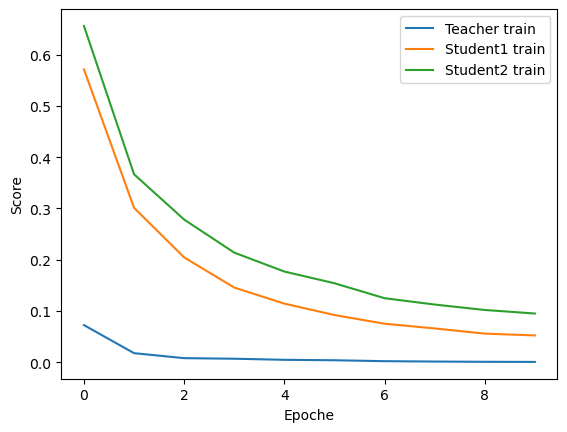

In [17]:
x = [i for i in range(len(scoreTS1))]

plt.plot(x, scoreTT, label='Teacher train')
plt.plot(x, scoreTS1, label='Student1 train')
plt.plot(x, scoreTS2, label='Student2 train')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

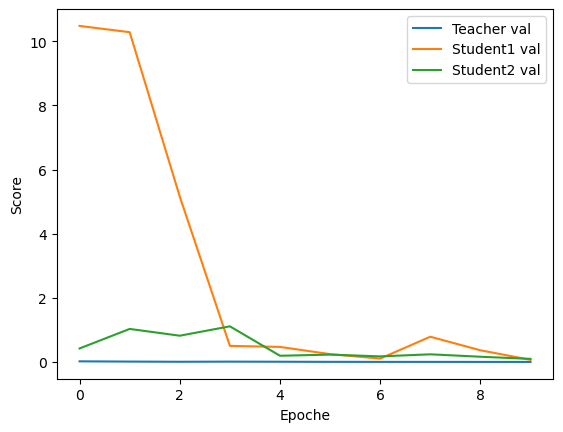

In [18]:
x = [i for i in range(len(scoreTS1))]

plt.plot(x, scoreVT, label='Teacher val')
plt.plot(x, scoreVS1, label='Student1 val')
plt.plot(x, scoreVS2, label='Student2 val')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

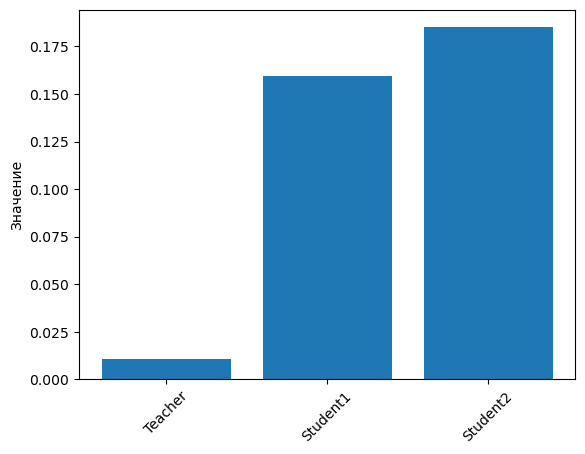

In [19]:
title = ['Teacher', 'Student1', 'Student2']

plt.bar(title, MAE)
plt.xticks(rotation=45)
plt.ylabel('Значение')
plt.show()